In [11]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(r'C:\Users\sushm\Downloads\bollywood1.csv')

In [13]:
df.head()

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,25-Oct-13,Zindagi Story Rang Again,N,Thriller,15,25.33,2644057,12425,1690
1,2,23-Aug-13,Udaan Story Junoon 2,LW,Romance,18,49.77,4283781,22844,1376
2,3,13-Dec-13,Dhadkan House Dulhan Reloaded,HS,Romance,63,114.57,13064026,69480,8767
3,4,20-Jun-14,Sapno Dhadkan,LW,Romance,42,81.79,9447173,56282,2864
4,5,18-Jul-14,Suraj Junction Don Again,N,Comedy,30,39.35,3896989,17144,2453


In [14]:
df.shape[0]

149

In [15]:
df.ReleaseTime.value_counts()

ReleaseTime
N     99
HS    18
FS    17
LW    15
Name: count, dtype: int64

In [16]:
df.Genre = df.Genre.str.strip()
df[df.ReleaseTime=='FS'].Genre.value_counts()

Genre
Drama       4
Thriller    4
Romance     3
Comedy      3
Action      3
Name: count, dtype: int64

In [17]:
pd.crosstab(df.Genre, df.ReleaseTime)

ReleaseTime,FS,HS,LW,N
Genre,,,,
Action,3,3,3,15
Comedy,3,5,5,23
Drama,4,6,1,24
Romance,3,3,4,15
Thriller,4,1,2,22


In [18]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df['Year'] = df['Release Date'].dt.year
df.Year.value_counts()

C:\Users\sushm\AppData\Local\Temp\ipykernel_10792\6110322.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release Date'] = pd.to_datetime(df['Release Date'])


Year
2014    70
2013    67
2015    12
Name: count, dtype: int64

In [19]:
df[df.Budget>=30]['Release Date'].dt.month.value_counts()

Release Date
2     8
8     7
1     6
11    6
6     5
7     5
10    4
9     4
3     3
5     3
4     3
12    2
Name: count, dtype: int64

In [20]:
df['ROI'] = (df.BoxOfficeCollection - df.Budget)/df.Budget
df.sort_values(by='ROI').MovieName[0:10]

100           Kahani Story Bazaar
87     Dhadkan Ke Rishton Forever
139        Gali Wala Bazaar Again
97            Kahani Files Punjab
114                 Dil Unlimited
127                   Dil Dhamaka
38               Junoon Unlimited
116                 Talaash Dilli
106                Himmat Kolkata
134                  Dhadkan 1947
Name: MovieName, dtype: object

In [21]:
df.groupby(by='ReleaseTime').ROI.mean()

ReleaseTime
FS    0.983990
HS    0.849544
LW    1.182988
N     0.539530
Name: ROI, dtype: float64

In [22]:
corr = df[['BoxOfficeCollection', 'YoutubeLikes']].corr()
corr

,BoxOfficeCollection,YoutubeLikes
BoxOfficeCollection,1.000000,0.942836
YoutubeLikes,0.942836,1.000000


<Axes: xlabel='Genre', ylabel='YoutubeViews'>

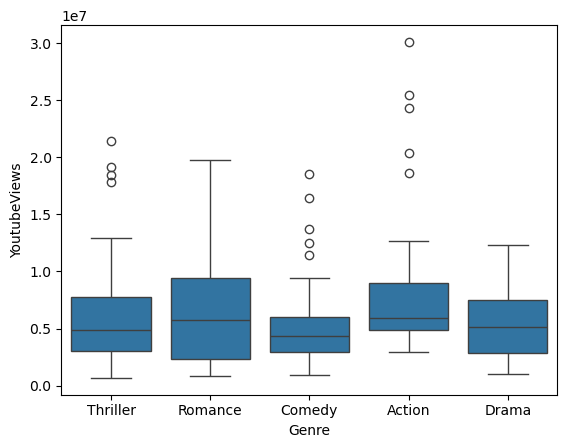

In [23]:
sns.boxplot(x='Genre', y='YoutubeViews', data=df)

<Axes: >

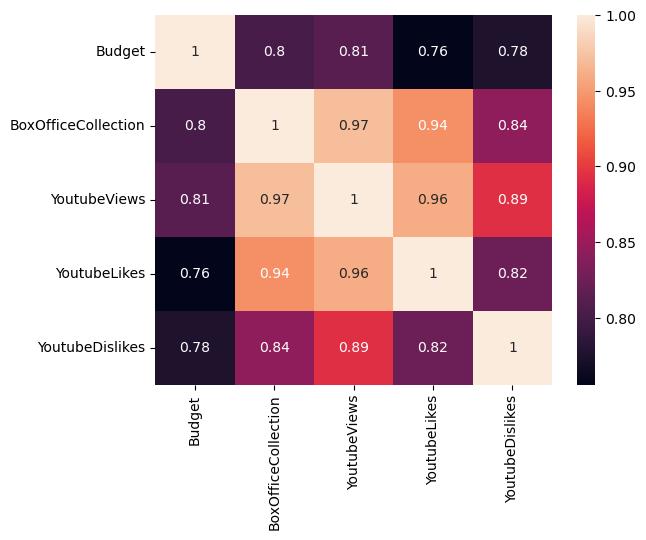

In [24]:
corr = df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']].corr()
sns.heatmap(corr, annot=True)

C:\Users\sushm\AppData\Local\Temp\ipykernel_10792\2378755974.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)


<Axes: xlabel='Year', ylabel='BoxOfficeCollection'>

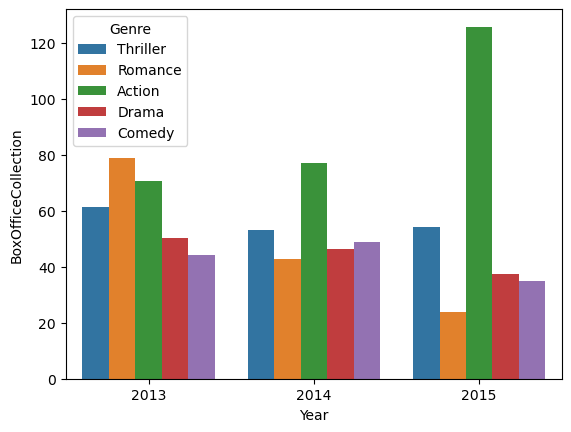

In [25]:
sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)

In [26]:
df.Year.value_counts()

Year
2014    70
2013    67
2015    12
Name: count, dtype: int64

<Axes: xlabel='Year', ylabel='count'>

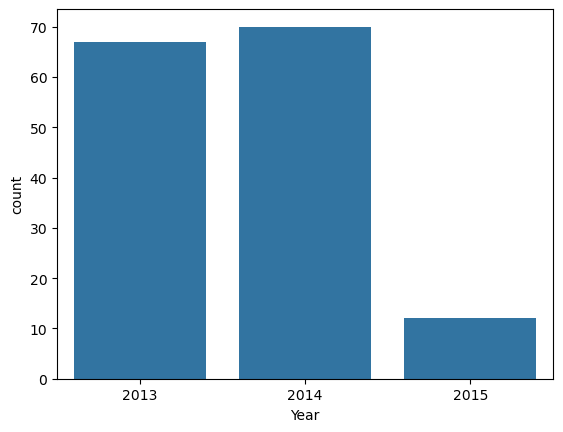

In [27]:
sns.countplot(x='Year', data=df)

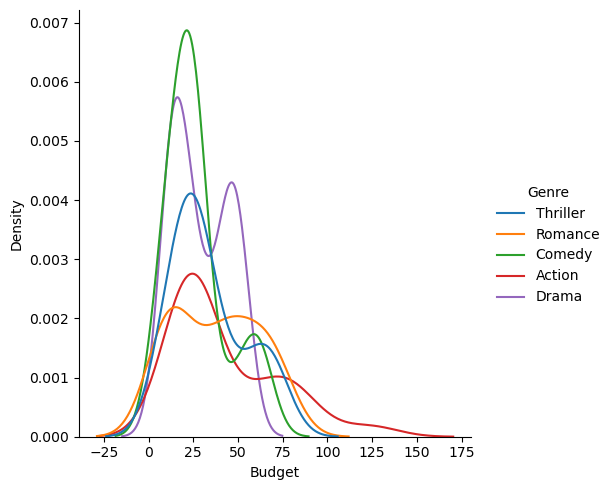

In [28]:
sns.displot(x='Budget', data=df, kind='kde', hue='Genre')

In [29]:
df.groupby(by='Year').YoutubeLikes.sum()

Year
2013    2333215
2014    2170851
2015     447992
Name: YoutubeLikes, dtype: int64

In [30]:
df.groupby(by='Year').YoutubeDislikes.sum()

Year
2013    213939
2014    179016
2015     33953
Name: YoutubeDislikes, dtype: int64

<Axes: >

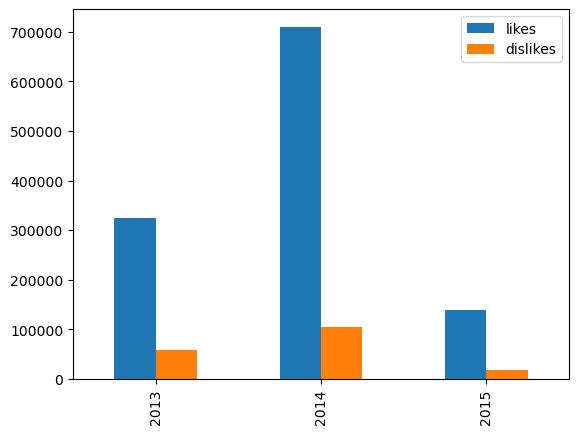

In [31]:
likes = [324180, 710142, 139431]
dislikes = [58156, 104682, 17127]
year = ['2013', '2014', '2015']
compare = pd.DataFrame({'likes':likes, 'dislikes':dislikes}, index=year)
compare.plot.bar()